# 02 — Filter Signals

**Stage 2 of 3.** Apply the `_forked` per-sensor preprocessing to one subject and compare before/after.

| Sensor | Processing | `_forked` source | Helper |
|---|---|---|---|
| EDA (chest 700 Hz, wrist 4 Hz) | Butterworth LP 1 Hz order 6 → `nk.standardize` → `nk.eda_phasic` (SCR / SCL) | `compute_features` + `utils.butter_lowpass_filter` | `wp.eda_decompose` |
| ACC (chest 700 Hz, wrist 32 Hz) | FIR LP 0.4 Hz, 64 taps (exactly as in `_forked`) | `utils.filterSignalFIR` | `wp.filter_signal_fir` |
| ECG, EMG, Resp, Temp (chest), BVP, TEMP (wrist) | passthrough — `_forked` filters ECG/Resp later inside heartpy / biosppy | `ecg.py`, `respiration.py` | — |

This stage reproduces the original `_forked` behaviour exactly (including its quirks — see the note at the bottom of `00_overview.ipynb`).

In [1]:
import sys
from pathlib import Path
HERE = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Scripts' / 'Preprocess').exists()) / 'Scripts' / 'Preprocess'
sys.path.insert(0, str(HERE))

import numpy as np
import matplotlib.pyplot as plt
import wesad_preprocess as wp

SUBJECT_ID = 2

data = wp.load_subject(SUBJECT_ID)

In [8]:
def compare(raw, filt, fs, title, start_s=600, dur_s=60, labels=('raw', 'filtered'), twin=False):
    """Plot a `dur_s`-second excerpt starting at `start_s` seconds.

    twin=True puts the filtered signal on a secondary y-axis (useful when the
    filtered amplitude is much smaller than the raw one, e.g. ACC).
    """
    a, b = int(start_s * fs), int((start_s + dur_s) * fs)
    t = np.arange(a, b) / fs
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.plot(t, np.asarray(raw)[a:b], lw=0.8, alpha=0.6, color='tab:blue', label=labels[0])
    ax.set_xlabel('time (s)'); ax.set_ylabel(labels[0], color='tab:blue')
    if twin:
        ax2 = ax.twinx()
        ax2.plot(t, np.asarray(filt)[a:b], lw=1.2, color='tab:orange', label=labels[1])
        ax2.set_ylabel(labels[1], color='tab:orange')
        lines = ax.get_lines() + ax2.get_lines()
        ax.legend(lines, [l.get_label() for l in lines], loc='upper right')
    else:
        ax.plot(t, np.asarray(filt)[a:b], lw=1.2, color='tab:orange', label=labels[1])
        ax.legend()
    ax.set_title(title); fig.tight_layout(); plt.show()

## 1. EDA — Butterworth low-pass + SCR/SCL decomposition

From `compute_features`:
```python
eda_df['EDA'] = utils.butter_lowpass_filter(eda_df['EDA'], 1.0, fs, 6)
eda_data = nk.eda_phasic(nk.standardize(eda_df['EDA']), sampling_rate=fs)
```

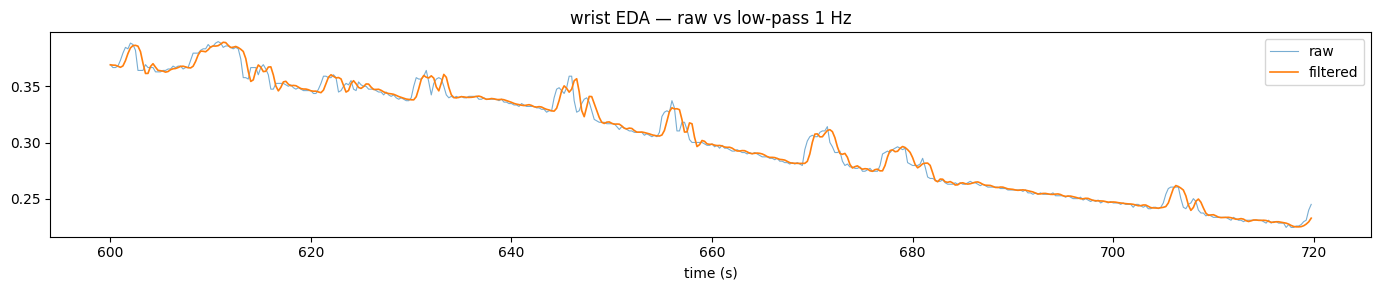

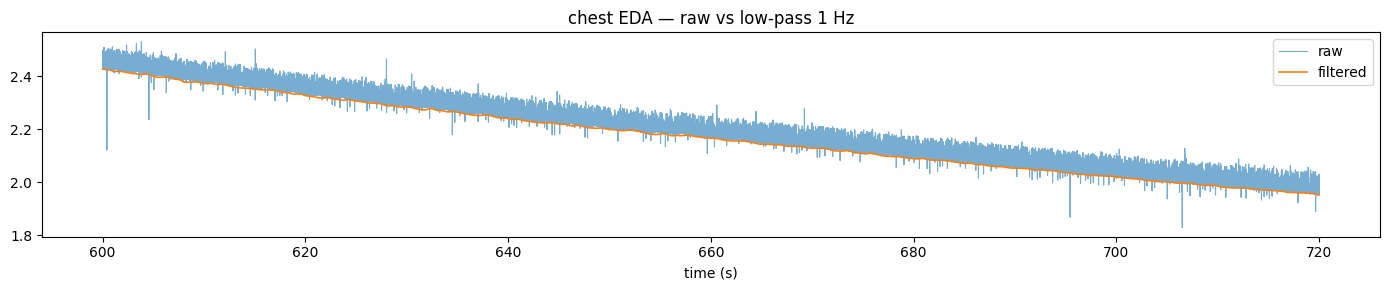

In [3]:
eda_res = {}
for loc in ('wrist', 'chest'):
    fs = wp.FS[loc]['EDA']
    raw = np.asarray(data['signal'][loc]['EDA']).ravel()
    eda_res[loc] = wp.eda_decompose(raw, fs)
    compare(raw, eda_res[loc]['EDA'], fs, f'{loc} EDA — raw vs low-pass 1 Hz', dur_s=120)

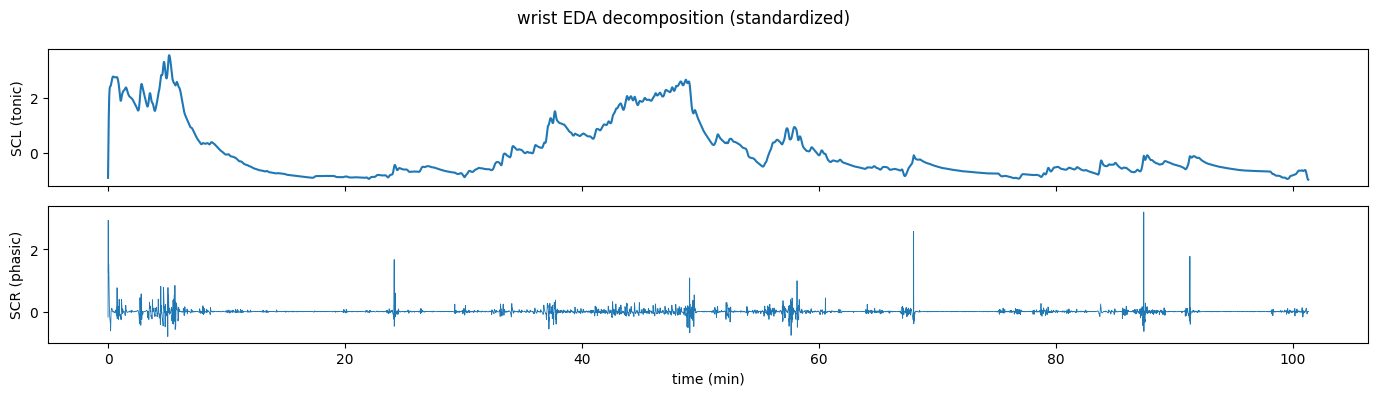

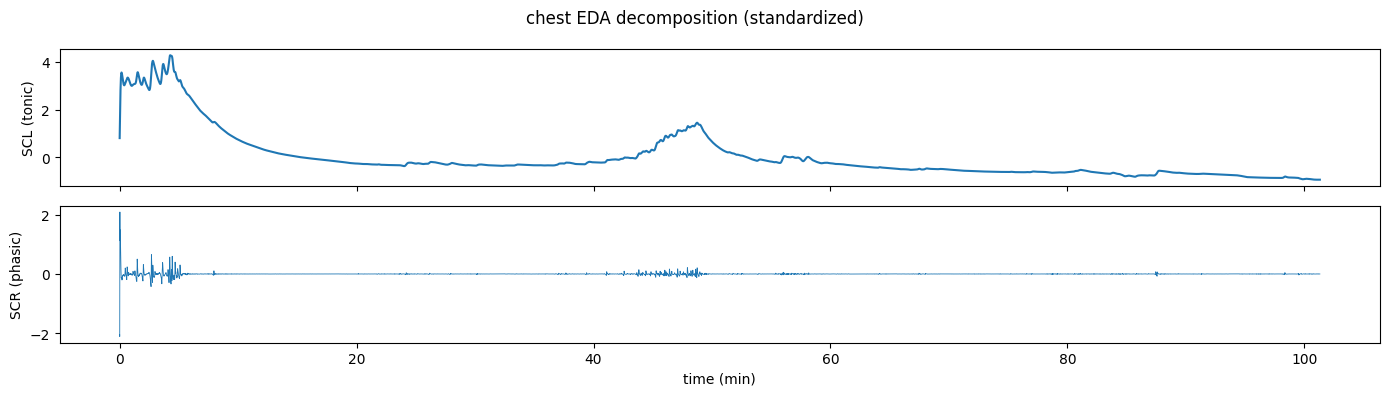

In [4]:
for loc in ('wrist', 'chest'):
    fs = wp.FS[loc]['EDA']
    r = eda_res[loc]
    step = max(1, len(r['EDA_SCL']) // 20_000)
    t = np.arange(0, len(r['EDA_SCL']), step) / fs / 60
    fig, ax = plt.subplots(2, 1, figsize=(14, 4), sharex=True)
    ax[0].plot(t, r['EDA_SCL'][::step]); ax[0].set_ylabel('SCL (tonic)')
    ax[1].plot(t, r['EDA_SCR'][::step], lw=0.6); ax[1].set_ylabel('SCR (phasic)')
    ax[1].set_xlabel('time (min)'); fig.suptitle(f'{loc} EDA decomposition (standardized)'); fig.tight_layout(); plt.show()

## 2. ACC — FIR low-pass (as in `_forked`)

Original:
```python
for _ in acc_df.columns:
    acc_df[_] = utils.filterSignalFIR(acc_df.values)   # 2-D array, filtered across x/y/z, fs always 32 Hz
```
`wp.filter_signal_fir(acc)` reproduces this exactly (see the note at the bottom of `00_overview.ipynb`).

> **Why the filtered ACC looks like 0:** because `lfilter` runs across x/y/z instead of along time, the output is essentially `fir[0] × raw_x` with `fir[0] ≈ 0.00069`. The filtered amplitude is ~1000× smaller than the raw one, so the plots below use a **secondary y-axis** (`twin=True`) to make it visible. This is the faithful `_forked` behaviour, not a plotting bug.

wrist: raw abs-max [128. 128. 128.]  ->  filtered abs-max [0.088071 0.147992 0.225319]


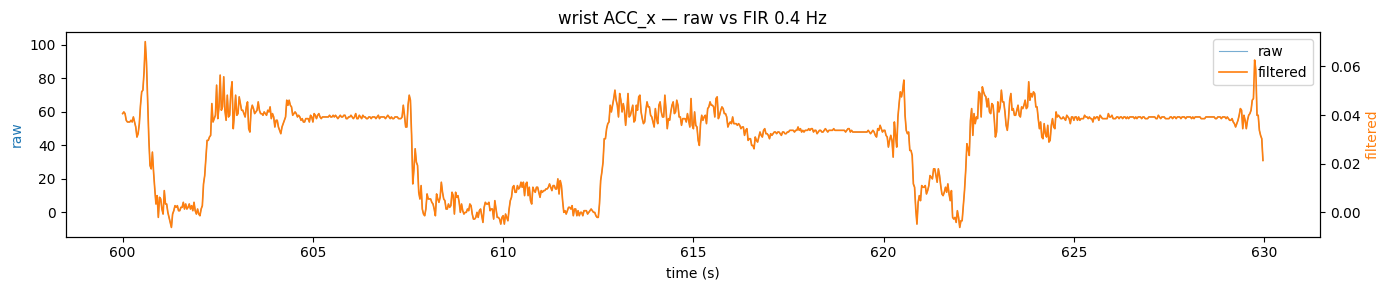

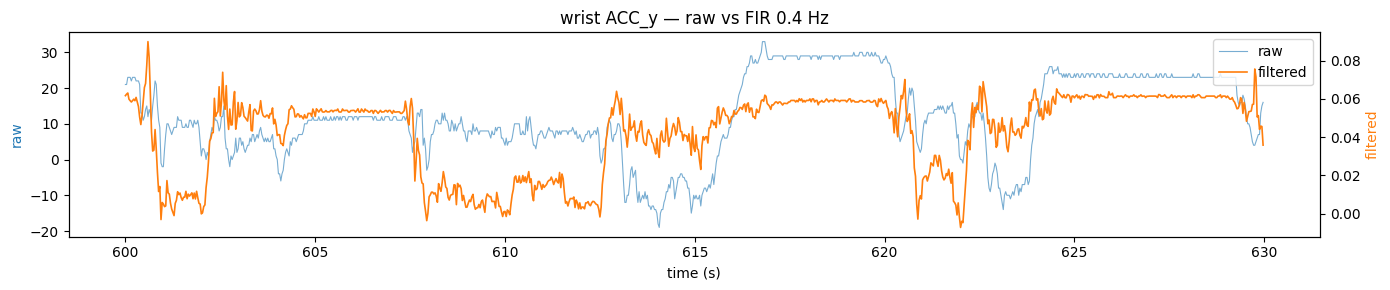

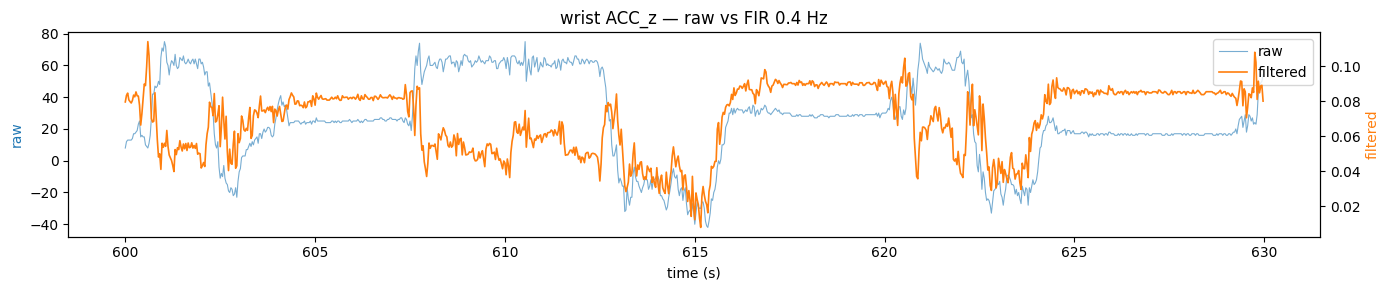

chest: raw abs-max [2.03  0.66  1.247]  ->  filtered abs-max [0.001397 0.001978 0.002964]


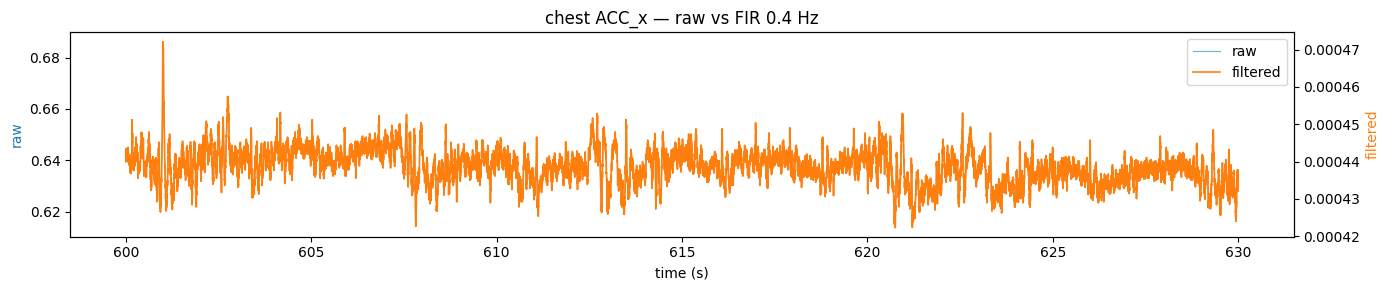

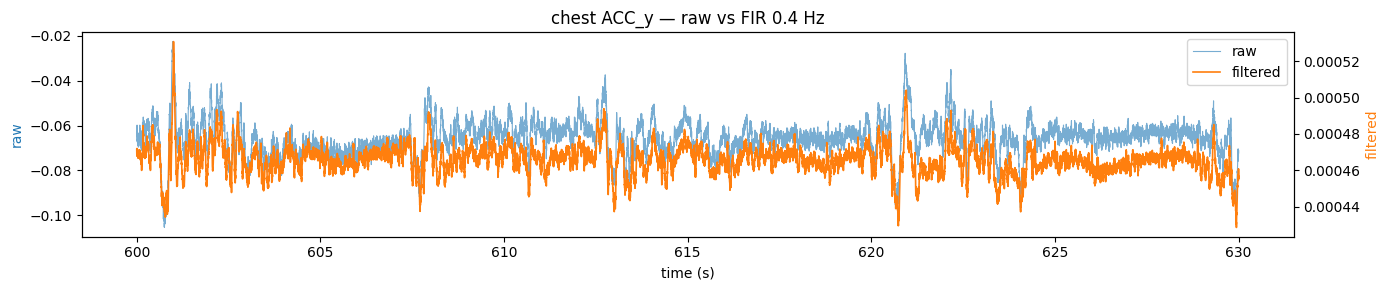

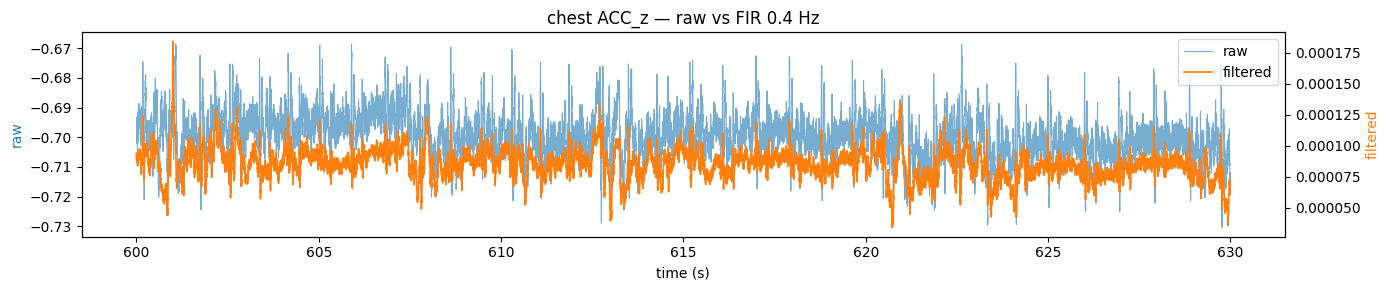

In [9]:
acc_res = {}
for loc in ('wrist', 'chest'):
    fs = wp.FS[loc]['ACC']
    raw = np.asarray(data['signal'][loc]['ACC'], dtype=float)
    acc_res[loc] = wp.filter_signal_fir(raw)
    print(f'{loc}: raw abs-max {np.abs(raw).max(axis=0).round(3)}  ->  '
          f'filtered abs-max {np.abs(acc_res[loc]).max(axis=0).round(6)}')
    for i, ax_name in enumerate('xyz'):
        # twin=True: the filtered amplitude is ~1000x smaller, so it needs its own axis
        compare(raw[:, i], acc_res[loc][:, i], fs, f'{loc} ACC_{ax_name} — raw vs FIR 0.4 Hz',
                dur_s=30, twin=True)

## 3. Passthrough signals

`_forked` does not filter these in its preprocessing step:

- **ECG** → `heartpy.process(..., 700)` at feature stage (`fb_code/ecg.py`)
- **Resp** → `biosppy.signals.resp.resp(...)` band-pass at feature stage (`fb_code/respiration.py`)
- **EMG, Temp (chest), BVP, TEMP (wrist)** → only window statistics

They are kept unchanged. Quick look below to confirm they are usable.

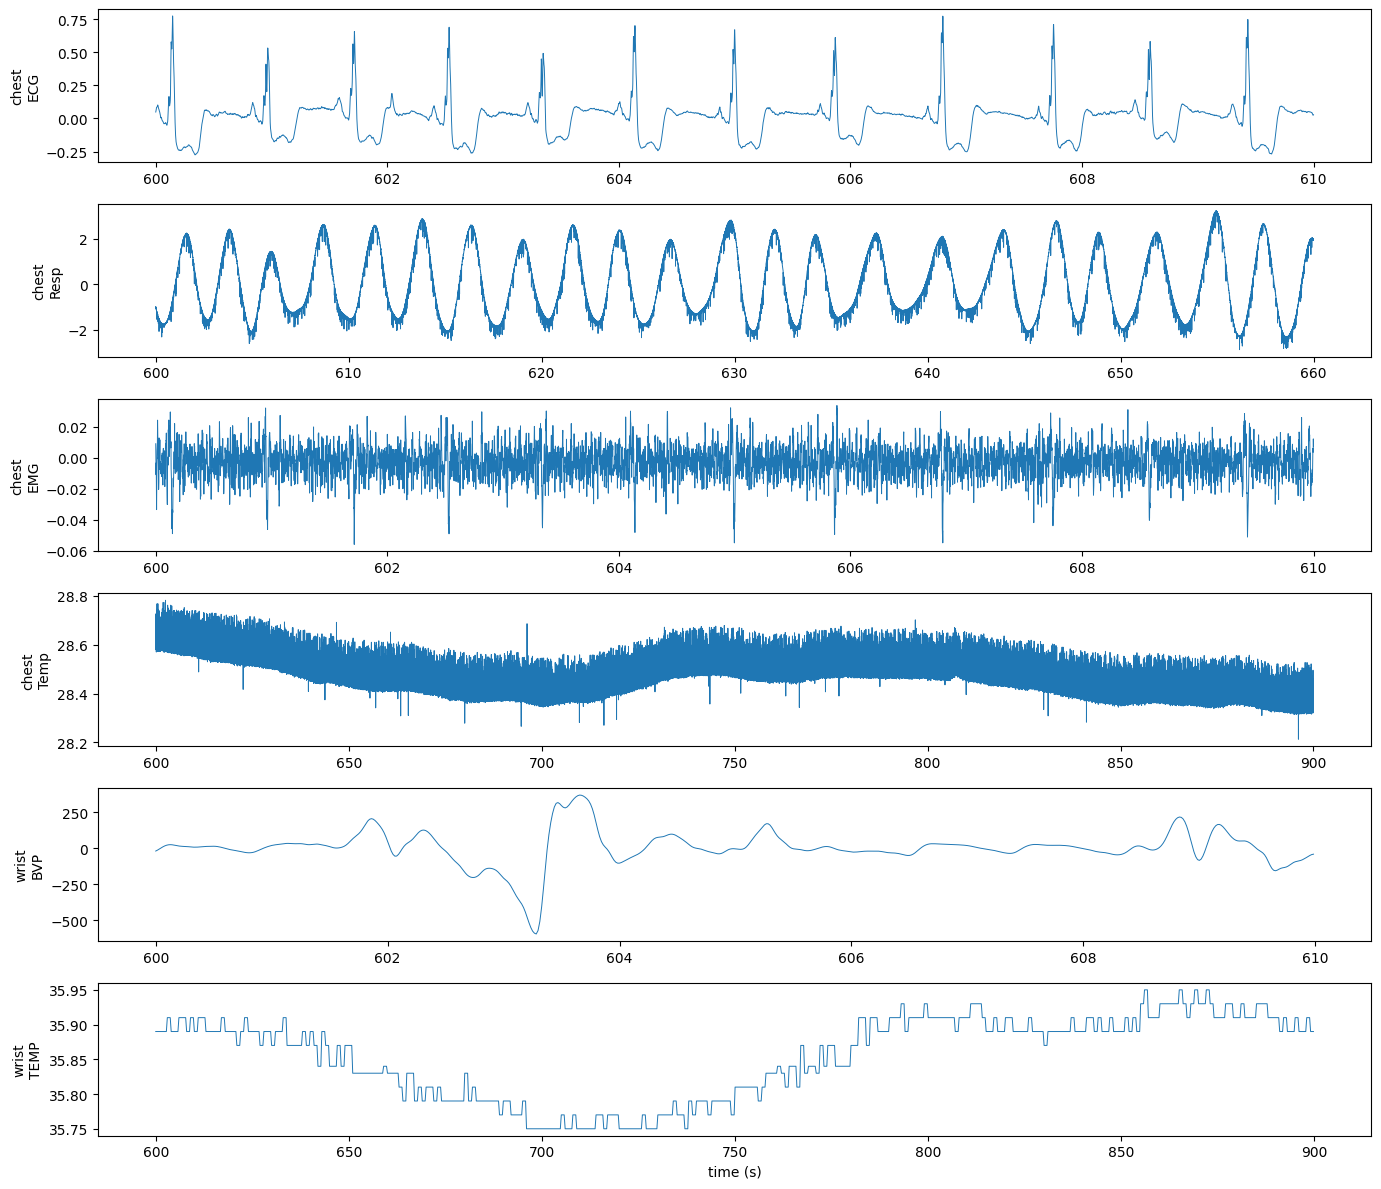

In [10]:
passthrough = [('chest', 'ECG', 10), ('chest', 'Resp', 60), ('chest', 'EMG', 10),
               ('chest', 'Temp', 300), ('wrist', 'BVP', 10), ('wrist', 'TEMP', 300)]
fig, axes = plt.subplots(len(passthrough), 1, figsize=(14, 2.0 * len(passthrough)))
for ax, (loc, name, dur) in zip(axes, passthrough):
    fs = wp.FS[loc][name]
    arr = np.asarray(data['signal'][loc][name]).ravel()
    a = 600 * fs
    ax.plot(np.arange(a, a + dur * fs) / fs, arr[a:a + dur * fs], lw=0.7)
    ax.set_ylabel(f'{loc}\n{name}')
axes[-1].set_xlabel('time (s)'); fig.tight_layout(); plt.show()

## 4. All-in-one

`wp.filter_subject` runs everything above for every sensor. This is what stage 3 uses.

In [11]:
filtered = wp.filter_subject(data)
for loc in ('chest', 'wrist'):
    print(loc, {k: v.shape for k, v in filtered[loc].items()})

chest {'ACC': (4255300, 3), 'ECG': (4255300,), 'EMG': (4255300,), 'EDA': (4255300,), 'EDA_SCR': (4255300,), 'EDA_SCL': (4255300,), 'Temp': (4255300,), 'Resp': (4255300,)}
wrist {'ACC': (194528, 3), 'BVP': (389056,), 'EDA': (24316,), 'EDA_SCR': (24316,), 'EDA_SCL': (24316,), 'TEMP': (24316,)}


In [12]:
del data, filtered, eda_res, acc_res